# Konsistenz eines Modells über mehrere Runs

Vergleicht mehrere Wiederholungen **desselben** Modells auf **derselben** Dateimenge
und beantwortet die Frage: *Wie reproduzierbar ist das Ergebnis?*

Hintergrund: Von den vier Dimensionen ist nur **Aussagekraft** LLM-gestützt
(ein `ExpressivenessAssessment` je Datensatz). Auffindbarkeit, Zugänglichkeit und
Wiederverwendbarkeit werden deterministisch aus dem RDF berechnet. Sie *müssen*
über Runs identisch sein — jede Abweichung dort ist kein Modellrauschen, sondern
ein Hinweis auf etwas anderes (z. B. wechselnde HTTP-Probe-Ergebnisse). Das
Notebook trennt beides deshalb sauber und schreibt die Modellvarianz nicht
fälschlich der gesamten Bewertung zu.

**Analysen**

1. Run-Ebene — schwankt die Kennzahl, die in der Arbeit berichtet wird?
2. Deterministisch vs. LLM — woher stammt die Varianz überhaupt?
3. Datei-Ebene — Streuung je Datei (die eigentliche Reproduzierbarkeit)
4. Paarweiser Vergleich — MAE und Spearman ρ (Rangstabilität)
5. Kriterien-Ebene — bei welchem `expr_*`-Kriterium schwankt das Modell?

**Eingabe:** `RUNS` und `DATEI_FILTER` in der nächsten Zelle.
Runs unterschiedlicher Größe sind erlaubt — verglichen wird immer die
Schnittmenge nach Filter (z. B. ein 50-Datei-Run gegen zwei 30-Datei-Runs).

In [ ]:
from pathlib import Path


# ---------------------------------------------------------------------------
# EINGABE
# ---------------------------------------------------------------------------
# Wiederholungen desselben Modells (Run-Name unterhalb von outputs/runs/ oder Pfad).
RUNS = [
    "run_2026-07-16_13-23-41_state-evaluation-final_EVAL_sonnet4-6",  # 50 Dateien
    "run_2026-07-20_08-41-30_state-evaluation-final_EVAL_sonnet4-6",  # 30 Dateien
    "run_2026-07-20_09-01-17_state-evaluation-final_EVAL_sonnet4-6",  # 30 Dateien
]

RUNS = [
    "run_2026-07-16_11-10-53_state-evaluation-final_EVAL_gpt5-5", 
    "run_2026-07-20_11-43-12_state-evaluation-final_EVAL_gpt5-5",
    "run_2026-07-20_11-55-49_state-evaluation-final_EVAL_gpt5-5"
]

# Teilstichprobe: nur Dateien mit _02/_03/_04 am Ende. Groessere Runs werden
# dadurch automatisch auf denselben Teilsatz reduziert.
DATEI_FILTER = r"_0[234]\.rdf$"

# Optional: PNGs zusaetzlich in diesen Ordner schreiben (None = nur anzeigen).
ROOT = Path.cwd().parents[1]
AUSGABE_ORDNER = ROOT / "outputs" / "model_comparison" / "plots"

In [2]:
import json
import re
import statistics as st
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

# Repo-Root relativ zum Notebook (playground/notebooks -> ../../)
REPO_ROOT = Path.cwd().parents[1]
RUNS_DIR = REPO_ROOT / "outputs" / "runs"

if len(RUNS) < 2:
    raise ValueError("Fuer einen Konsistenzvergleich werden mindestens zwei Runs benoetigt.")

muster = re.compile(DATEI_FILTER)


def run_pfad(run: str) -> Path:
    p = Path(run) if Path(run).is_absolute() else RUNS_DIR / run
    if not p.is_dir():
        raise FileNotFoundError(f"Run-Ordner nicht gefunden: {p}")
    return p


run_dirs = [run_pfad(r) for r in RUNS]

# Kurz-Handles R1/R2/... fuer die Tabellen: die vollen Run-Namen unterscheiden
# sich erst weit hinten und waeren in einer Spalte abgeschnitten nicht mehr
# auseinanderzuhalten. Datum/Uhrzeit als Gedaechtnisstuetze in der Legende.
def zeitstempel(name: str) -> str:
    m = re.search(r"(\d{4})-(\d{2})-(\d{2})_(\d{2})-(\d{2})", name)
    return f"{m.group(3)}.{m.group(2)}. {m.group(4)}:{m.group(5)}" if m else name


kurz = [f"R{i + 1}" for i in range(len(run_dirs))]

# Datei-Ergebnisse je Run, bereits auf den Teilsatz gefiltert.
dateien_je_run = []
for d in run_dirs:
    agg = json.loads((d / "run_aggregate.json").read_text(encoding="utf-8"))
    dateien_je_run.append({k: v for k, v in (agg.get("files") or {}).items() if muster.search(k)})

# Verglichen wird ausschliesslich die Schnittmenge - sonst wuerden Runs
# unterschiedlicher Groesse ueber unterschiedliche Grundgesamtheiten gemittelt.
gemeinsam = sorted(set.intersection(*(set(f) for f in dateien_je_run)))
if not gemeinsam:
    raise ValueError("Keine gemeinsamen Dateien nach Filter - stimmt DATEI_FILTER?")

print(f"Runs      : {len(run_dirs)}")
for k, d, f in zip(kurz, run_dirs, dateien_je_run):
    print(f"  {k} = {zeitstempel(d.name)}  ({len(f)} Dateien nach Filter)  {d.name}")
print(f"\nFilter    : {DATEI_FILTER}")
print(f"Vergleich : {len(gemeinsam)} gemeinsame Dateien")

fehlend = [
    (k, sorted(set(f) - set(gemeinsam)))
    for k, f in zip(kurz, dateien_je_run)
    if set(f) - set(gemeinsam)
]
for k, extra in fehlend:
    print(f"  Hinweis: {k} hat {len(extra)} zusaetzliche Datei(en), die ignoriert werden.")

Runs      : 3
  R1 = 16.07. 13:23  (30 Dateien nach Filter)  run_2026-07-16_13-23-41_state-evaluation-final_EVAL_sonnet4-6
  R2 = 20.07. 08:41  (30 Dateien nach Filter)  run_2026-07-20_08-41-30_state-evaluation-final_EVAL_sonnet4-6
  R3 = 20.07. 09:01  (30 Dateien nach Filter)  run_2026-07-20_09-01-17_state-evaluation-final_EVAL_sonnet4-6

Filter    : _0[234]\.rdf$
Vergleich : 30 gemeinsame Dateien


In [3]:
# Hilfsfunktionen: Kennzahlen und deutsche Beschriftung.

DIMENSION_DE = {
    "findability": "Auffindbarkeit",
    "accessibility": "Zugänglichkeit",
    "reusability": "Wiederverwendbarkeit",
    "expressiveness": "Aussagekraft",
}
# Nur diese Dimension wird vom LLM bewertet - alle anderen sind deterministisch.
LLM_DIMENSION = "expressiveness"

BALKEN = "#4c72b0"
AKZENT = "#c0504d"
MITTEL = "#4c9f70"


def dim_de(dim: str) -> str:
    return DIMENSION_DE.get(dim, dim)


def raenge(werte):
    """Raenge mit Mittelwert bei Bindungen (fuer Spearman)."""
    paare = sorted(range(len(werte)), key=lambda i: werte[i])
    r = [0.0] * len(werte)
    i = 0
    while i < len(paare):
        j = i
        while j + 1 < len(paare) and werte[paare[j + 1]] == werte[paare[i]]:
            j += 1
        mittel = (i + j) / 2 + 1
        for k in range(i, j + 1):
            r[paare[k]] = mittel
        i = j + 1
    return r


def pearson(a, b):
    ma, mb = st.mean(a), st.mean(b)
    zaehler = sum((x - ma) * (y - mb) for x, y in zip(a, b))
    nenner = (sum((x - ma) ** 2 for x in a) * sum((y - mb) ** 2 for y in b)) ** 0.5
    return zaehler / nenner if nenner else float("nan")


def spearman(a, b):
    """Rangkorrelation - misst, ob die *Reihenfolge* der Dateien stabil bleibt."""
    return pearson(raenge(a), raenge(b))


def werte_je_datei(schluessel=None, dimension=None):
    """Liste je Datei mit einem Wert pro Run."""
    out = {}
    for f in gemeinsam:
        reihe = []
        for dateien in dateien_je_run:
            eintrag = dateien[f]
            if dimension is not None:
                reihe.append(float((eintrag.get("dimension_scores") or {}).get(dimension, 0.0)))
            else:
                reihe.append(float(eintrag[schluessel]))
        out[f] = reihe
    return out


def kuerzen(name: str, limit: int = 28) -> str:
    return name if len(name) <= limit else name[: limit - 1] + "…"


out_dir = None
if AUSGABE_ORDNER:
    out_dir = Path(AUSGABE_ORDNER) if Path(AUSGABE_ORDNER).is_absolute() else REPO_ROOT / AUSGABE_ORDNER
    out_dir.mkdir(parents=True, exist_ok=True)


def speichern(fig, name: str) -> None:
    if out_dir is not None:
        pfad = out_dir / name
        fig.savefig(pfad, dpi=150, bbox_inches="tight")
        print(f"geschrieben: {pfad}")


dimensionen = sorted({d for f in dateien_je_run for e in f.values() for d in (e.get("dimension_scores") or {})}, key=dim_de)
print("Dimensionen:", ", ".join(dim_de(d) for d in dimensionen))

Dimensionen: Auffindbarkeit, Aussagekraft, Wiederverwendbarkeit, Zugänglichkeit


## 1 — Run-Ebene

Die Zahl, die üblicherweise berichtet wird, ist der Mittelwert über alle Dateien.
Die Spanne dieser Run-Mittelwerte ist die **Unsicherheit dieser Kennzahl**: Ein
Modellvergleich, dessen Abstände kleiner sind als diese Spanne, misst Rauschen.

In [4]:
gesamt = werte_je_datei("overall_score")
run_mittel = [st.mean([gesamt[f][i] for f in gemeinsam]) for i in range(len(RUNS))]

print(f"{'Run':<8}{'Zeitpunkt':<16}{'Mittelwert':>12}{'Median':>10}{'Min':>8}{'Max':>8}")
print("-" * 62)
for i, (k, d) in enumerate(zip(kurz, run_dirs)):
    sp = [gesamt[f][i] for f in gemeinsam]
    print(f"{k:<8}{zeitstempel(d.name):<16}{st.mean(sp):>12.4f}{st.median(sp):>10.4f}"
          f"{min(sp):>8.4f}{max(sp):>8.4f}")

spanne = max(run_mittel) - min(run_mittel)
print("-" * 62)
print(f"{'Spanne der Run-Mittelwerte':<36}{spanne:>12.4f}")
print(f"{'Standardabweichung':<36}{st.stdev(run_mittel):>12.4f}")
print()
print(f"Ein Modellunterschied unterhalb von {spanne:.4f} ist mit diesen Daten")
print("nicht von Run-zu-Run-Rauschen unterscheidbar.")

Run     Zeitpunkt         Mittelwert    Median     Min     Max
--------------------------------------------------------------
R1      16.07. 13:23          0.6170    0.6318  0.4435  0.7595
R2      20.07. 08:41          0.6223    0.6370  0.4378  0.7605
R3      20.07. 09:01          0.6233    0.6407  0.4409  0.7666
--------------------------------------------------------------
Spanne der Run-Mittelwerte                0.0063
Standardabweichung                        0.0034

Ein Modellunterschied unterhalb von 0.0063 ist mit diesen Daten
nicht von Run-zu-Run-Rauschen unterscheidbar.


## 2 — Woher kommt die Varianz?

Entscheidend für die Interpretation: Nur **Aussagekraft** ist LLM-gestützt.
Zeigen die drei deterministischen Dimensionen eine Abweichung von exakt 0, ist
die gesamte beobachtete Streuung dem Modell zuzuschreiben — und die
Pipeline drumherum ist reproduzierbar.

In [5]:
print(f"{'Dimension':<24}{'Dateien≠':>10}{'max. Spanne':>14}{'Ø Stdabw.':>12}   Typ")
print("-" * 74)
for dim in dimensionen:
    w = werte_je_datei(dimension=dim)
    spannen = [max(v) - min(v) for v in w.values()]
    abweichend = sum(1 for s in spannen if s > 1e-9)
    stdabw = st.mean([st.stdev(v) for v in w.values()])
    typ = "LLM" if dim == LLM_DIMENSION else "deterministisch"
    print(f"{dim_de(dim):<24}{abweichend:>4}/{len(gemeinsam):<5}{max(spannen):>14.4f}{stdabw:>12.4f}   {typ}")

det = [d for d in dimensionen if d != LLM_DIMENSION]
det_abweichend = sum(
    1 for d in det for v in werte_je_datei(dimension=d).values() if max(v) - min(v) > 1e-9
)
print()
if det_abweichend == 0:
    print("✓ Alle deterministischen Dimensionen sind über die Runs identisch.")
    print("  Die gesamte Streuung stammt damit aus der LLM-Bewertung (Aussagekraft).")
else:
    print(f"⚠ {det_abweichend} Abweichung(en) in deterministischen Dimensionen.")
    print("  Das ist kein Modellrauschen - moegliche Ursachen: wechselnde HTTP-Probe-")
    print("  Ergebnisse (Erreichbarkeit von Download-/Access-URLs) oder eine geaenderte Config.")

Dimension                 Dateien≠   max. Spanne   Ø Stdabw.   Typ
--------------------------------------------------------------------------
Auffindbarkeit             0/30           0.0000      0.0000   deterministisch
Aussagekraft              30/30           0.1250      0.0268   LLM
Wiederverwendbarkeit       0/30           0.0000      0.0000   deterministisch
Zugänglichkeit             0/30           0.0000      0.0000   deterministisch

✓ Alle deterministischen Dimensionen sind über die Runs identisch.
  Die gesamte Streuung stammt damit aus der LLM-Bewertung (Aussagekraft).


## 3 — Datei-Ebene

Gleiche Run-Mittelwerte bedeuten nicht gleiche Einzelergebnisse: Abweichungen
nach oben und unten heben sich im Mittel auf. Erst die Streuung **je Datei**
zeigt, wie stabil eine einzelne Bewertung ist.

In [6]:
def streuungs_tabelle(werte, titel):
    stdabw = {f: st.stdev(v) for f, v in werte.items()}
    spannen = {f: max(v) - min(v) for f, v in werte.items()}
    print(f"{titel}")
    print(f"  Ø Standardabweichung je Datei : {st.mean(stdabw.values()):.4f}")
    print(f"  Ø Spanne je Datei             : {st.mean(spannen.values()):.4f}")
    print(f"  groesste Spanne               : {max(spannen.values()):.4f}")
    print(f"  Dateien voellig identisch     : {sum(1 for s in spannen.values() if s < 1e-9)}/{len(werte)}")
    return spannen


spannen_gesamt = streuungs_tabelle(gesamt, "Gesamtscore")
print()
spannen_expr = streuungs_tabelle(werte_je_datei(dimension=LLM_DIMENSION), f"{dim_de(LLM_DIMENSION)} (LLM)")

print("\nGroesste Abweichungen im Gesamtscore:")
print(f"  {'Datei':<40}{'Spanne':>9}   Werte je Run")
for f in sorted(spannen_gesamt, key=spannen_gesamt.get, reverse=True)[:8]:
    reihe = "  ".join(f"{v:.3f}" for v in gesamt[f])
    print(f"  {kuerzen(f, 39):<40}{spannen_gesamt[f]:>9.4f}   {reihe}")

Gesamtscore
  Ø Standardabweichung je Datei : 0.0082
  Ø Spanne je Datei             : 0.0160
  groesste Spanne               : 0.0385
  Dateien voellig identisch     : 0/30

Aussagekraft (LLM)
  Ø Standardabweichung je Datei : 0.0268
  Ø Spanne je Datei             : 0.0519
  groesste Spanne               : 0.1250
  Dateien voellig identisch     : 0/30

Groesste Abweichungen im Gesamtscore:
  Datei                                      Spanne   Werte je Run
  non_geo_rest_02.rdf                        0.0385   0.468  0.450  0.488
  geo_rest_02.rdf                            0.0328   0.529  0.554  0.521
  geo_open-data-brandenburg_03.rdf           0.0308   0.673  0.686  0.704
  geo_open-data-brandenburg_02.rdf           0.0308   0.642  0.657  0.673
  non_geo_gdi-de_03.rdf                      0.0282   0.623  0.639  0.611
  geo_gdi-de_02.rdf                          0.0282   0.611  0.622  0.640
  non_geo_open-data-bayern_02.rdf            0.0282   0.738  0.751  0.767
  non_geo_open-data-

geschrieben: /home/lbuerger/masterthesis/master_thesis_prototype/model_comparison/plots/konsistenz_gesamtscore_je_datei.png


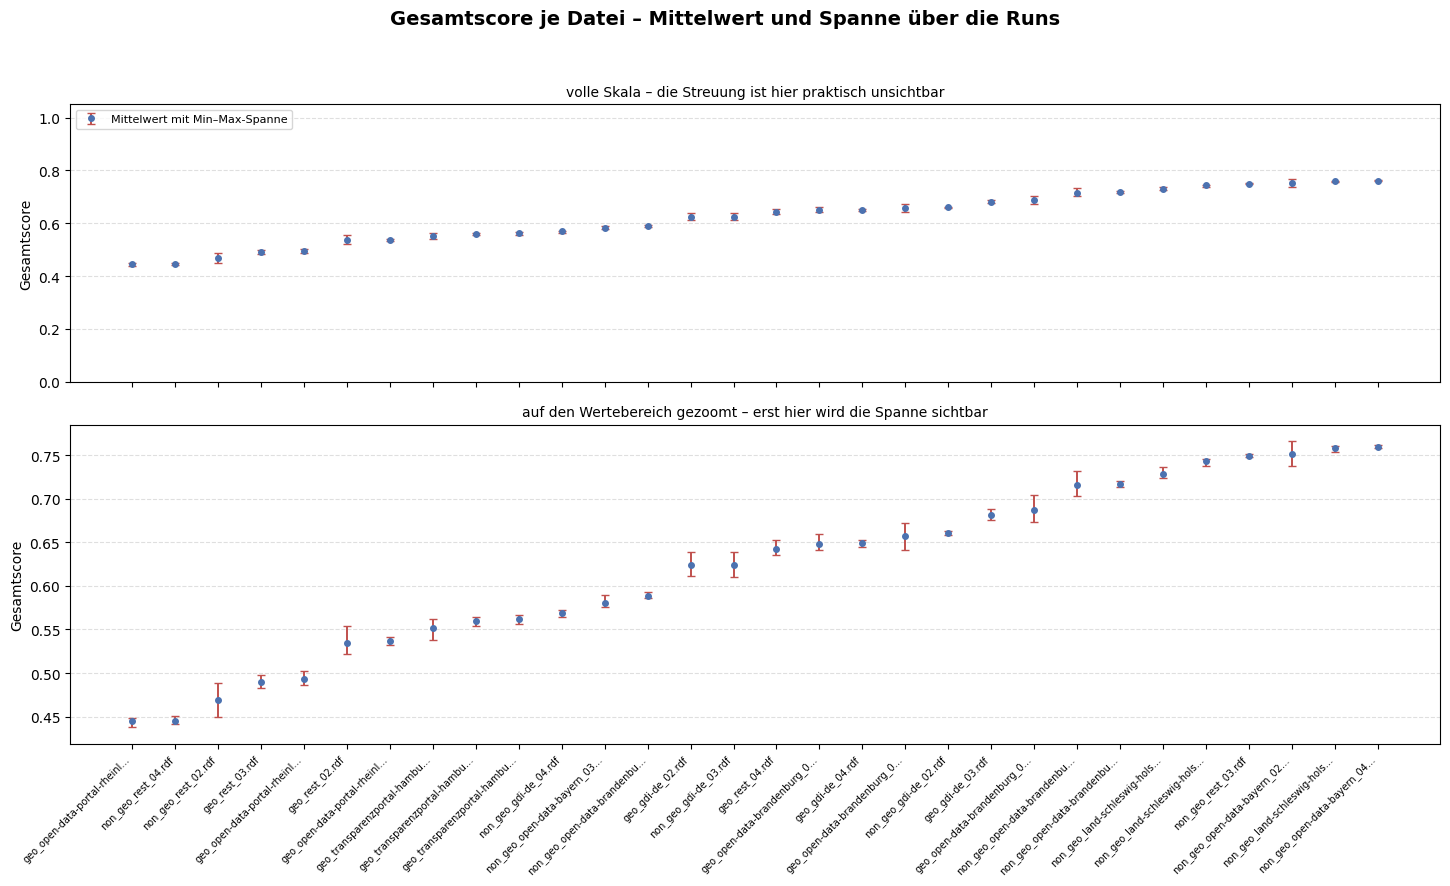

In [7]:
# Streuung je Datei als Fehlerbalken: Punkt = Mittelwert, Balken = Min..Max ueber die Runs.
# Zwei Panels, weil beide Aussagen zaehlen: oben die feste 0..1-Skala (auf der die
# Streuung verschwindet - genau das ist die Botschaft), unten auf den tatsaechlichen
# Wertebereich gezoomt, wo die Spanne ueberhaupt erst sichtbar wird.
namen = sorted(gemeinsam, key=lambda f: st.mean(gesamt[f]))
mittel = [st.mean(gesamt[f]) for f in namen]
unten = [st.mean(gesamt[f]) - min(gesamt[f]) for f in namen]
oben = [max(gesamt[f]) - st.mean(gesamt[f]) for f in namen]

breite = max(9.0, 0.42 * len(namen) + 2.0)
fig, (ax_voll, ax_zoom) = plt.subplots(
    2, 1, figsize=(breite, 9), sharex=True,
    gridspec_kw={"height_ratios": [1, 1.15]},
)
fig.suptitle("Gesamtscore je Datei – Mittelwert und Spanne über die Runs",
             fontsize=14, fontweight="bold")

x = np.arange(len(namen))
for ax in (ax_voll, ax_zoom):
    ax.errorbar(x, mittel, yerr=[unten, oben], fmt="o", color=BALKEN,
                ecolor=AKZENT, elinewidth=1.4, capsize=3, markersize=4,
                label="Mittelwert mit Min–Max-Spanne")
    ax.set_ylabel("Gesamtscore")
    ax.grid(axis="y", linestyle="--", alpha=0.4)

ax_voll.set_ylim(0, 1.05)
ax_voll.set_title("volle Skala – die Streuung ist hier praktisch unsichtbar", fontsize=10)
ax_voll.legend(loc="upper left", fontsize=8)

rand = (max(mittel) - min(mittel)) * 0.06
ax_zoom.set_ylim(min(m - u for m, u in zip(mittel, unten)) - rand,
                 max(m + o for m, o in zip(mittel, oben)) + rand)
ax_zoom.set_title("auf den Wertebereich gezoomt – erst hier wird die Spanne sichtbar",
                  fontsize=10)
ax_zoom.set_xticks(x)
ax_zoom.set_xticklabels([kuerzen(n) for n in namen], rotation=45, ha="right", fontsize=7)

fig.tight_layout(rect=(0, 0, 1, 0.95))
speichern(fig, "konsistenz_gesamtscore_je_datei.png")
plt.show()

## 4 — Paarweiser Vergleich

**MAE** misst die absolute Übereinstimmung (wie weit liegen die Scores auseinander),
**Spearman ρ** die Rangstabilität (bleibt die Reihenfolge der Dateien gleich).
Für Modellvergleiche ist ρ oft die relevantere Größe: Solange die Rangfolge stabil
ist, bleiben Aussagen wie „Datensatz A ist besser als B" belastbar.

In [8]:
def paar_tabelle(werte, titel):
    print(titel)
    print(f"  {'Run-Paar':<14}{'MAE':>9}{'max |Δ|':>10}{'Spearman ρ':>13}")
    print("  " + "-" * 44)
    for i, j in combinations(range(len(RUNS)), 2):
        a = [werte[f][i] for f in gemeinsam]
        b = [werte[f][j] for f in gemeinsam]
        diff = [abs(x - y) for x, y in zip(a, b)]
        print(f"  {kurz[i] + ' ↔ ' + kurz[j]:<14}{st.mean(diff):>9.4f}"
              f"{max(diff):>10.4f}{spearman(a, b):>13.4f}")


paar_tabelle(gesamt, "Gesamtscore")
print()
paar_tabelle(werte_je_datei(dimension=LLM_DIMENSION),
             f"{dim_de(LLM_DIMENSION)} — die LLM-Dimension, in der die Streuung entsteht")

Gesamtscore
  Run-Paar            MAE   max |Δ|   Spearman ρ
  --------------------------------------------
  R1 ↔ R2          0.0093    0.0282       0.9938
  R1 ↔ R3          0.0109    0.0308       0.9894
  R2 ↔ R3          0.0117    0.0385       0.9885

Aussagekraft — die LLM-Dimension, in der die Streuung entsteht
  Run-Paar            MAE   max |Δ|   Spearman ρ
  --------------------------------------------
  R1 ↔ R2          0.0303    0.0917       0.9783
  R1 ↔ R3          0.0354    0.1000       0.9367
  R2 ↔ R3          0.0382    0.1250       0.9550


## 5 — Kriterien-Ebene

Lokalisiert die Streuung: Bei welchem der sechs `expr_*`-Kriterien schwankt das
Modell, und wie oft kippt dabei die diskrete Bewertung (bestanden / teilweise /
nicht bestanden)? Ein Statuswechsel wiegt schwerer als eine kleine Score-Differenz,
weil er in der Auswertung als qualitativer Unterschied erscheint.

In [9]:
# Indikator-Ergebnisse je Datei aus den result.json der Runs einsammeln.
# Ordnername im Run entspricht dem Dateinamen ohne .rdf.
def indikatoren_je_run(run_dir: Path) -> dict:
    out = {}
    for ordner in run_dir.iterdir():
        if not ordner.is_dir():
            continue
        pfad = ordner / "result.json"
        if not pfad.exists():
            continue
        try:
            res = json.loads(pfad.read_text(encoding="utf-8"))
        except (json.JSONDecodeError, OSError):
            continue
        eintrag = {}
        for block in (res.get("by_dimension") or {}).values():
            for ind in block.get("indicators") or []:
                eintrag[ind["indicator_id"]] = {
                    "score": ind.get("score"),
                    "status": ind.get("status"),
                    "name_de": ind.get("name_de"),
                }
        out[f"{ordner.name}.rdf"] = eintrag
    return out


ind_je_run = [indikatoren_je_run(d) for d in run_dirs]

# Nur Dateien, die in allen Runs Indikatordaten haben.
ind_dateien = [f for f in gemeinsam if all(f in r for r in ind_je_run)]
expr_ids = sorted({
    i for r in ind_je_run for f in ind_dateien for i in r[f] if i.startswith("expr_")
})

print(f"Indikatordaten fuer {len(ind_dateien)}/{len(gemeinsam)} Dateien\n")
print(f"{'Kriterium':<34}{'Ø Stdabw.':>11}{'max |Δ|':>10}{'Status-Wechsel':>16}")
print("-" * 71)

for iid in expr_ids:
    stdabw, spannen, wechsel, n = [], [], 0, 0
    for f in ind_dateien:
        scores, status = [], []
        for r in ind_je_run:
            e = r[f].get(iid)
            if not e or e.get("score") is None:
                continue
            scores.append(float(e["score"]))
            status.append(e.get("status"))
        if len(scores) < 2:
            continue
        n += 1
        stdabw.append(st.stdev(scores))
        spannen.append(max(scores) - min(scores))
        if len(set(status)) > 1:
            wechsel += 1
    if not n:
        continue
    label = next(
        (r[f][iid]["name_de"] for r in ind_je_run for f in ind_dateien
         if r[f].get(iid, {}).get("name_de")),
        iid,
    )
    print(f"{kuerzen(label, 33):<34}{st.mean(stdabw):>11.4f}{max(spannen):>10.4f}"
          f"{wechsel:>10}/{n:<5}")

Indikatordaten fuer 30/30 Dateien

Kriterium                           Ø Stdabw.   max |Δ|  Status-Wechsel
-----------------------------------------------------------------------
Kontextuelle Qualifizierer             0.0793    0.4000        14/30   
Beschreibungs-Qualität                 0.0241    0.1000         1/30   
Schlagwort-Qualität                    0.0391    0.2500         4/30   
Thematische Konsistenz                 0.0342    0.2000         6/30   
Kohärenz von Titel und Beschreib…      0.0513    0.5000        11/30   
Titel-Qualität                         0.0278    0.2500         5/30   


geschrieben: /home/lbuerger/masterthesis/master_thesis_prototype/model_comparison/plots/konsistenz_statuswechsel.png


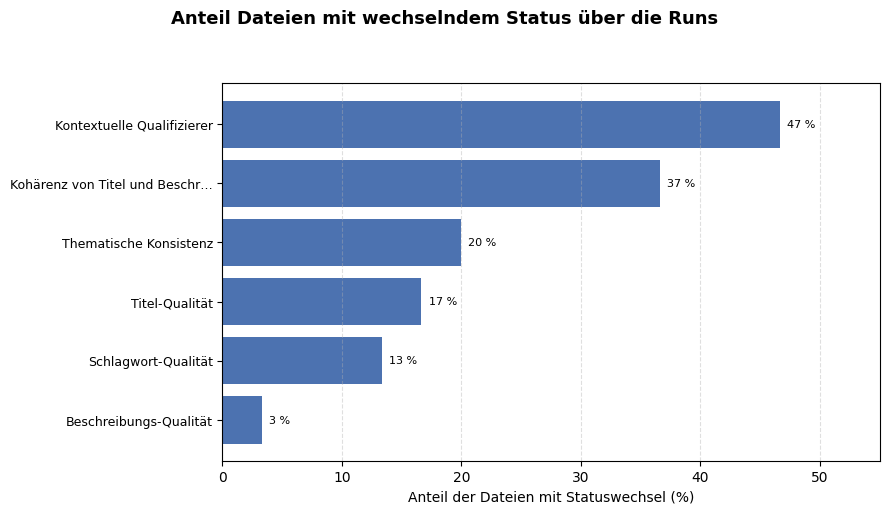

In [10]:
# Statuswechsel je Kriterium als Balken - zeigt, wo die Bewertung qualitativ kippt.
label, quote = [], []
for iid in expr_ids:
    wechsel, n = 0, 0
    for f in ind_dateien:
        status = [r[f][iid]["status"] for r in ind_je_run if r[f].get(iid)]
        if len(status) < 2:
            continue
        n += 1
        if len(set(status)) > 1:
            wechsel += 1
    if not n:
        continue
    name = next(
        (r[f][iid]["name_de"] for r in ind_je_run for f in ind_dateien
         if r[f].get(iid, {}).get("name_de")),
        iid,
    )
    label.append(kuerzen(name, 30))
    quote.append(100 * wechsel / n)

reihenfolge = np.argsort(quote)
label = [label[i] for i in reihenfolge]
quote = [quote[i] for i in reihenfolge]

fig, ax = plt.subplots(figsize=(9, 0.5 * len(label) + 2.2))
fig.suptitle("Anteil Dateien mit wechselndem Status über die Runs",
             fontsize=13, fontweight="bold")
y = np.arange(len(label))
bars = ax.barh(y, quote, color=BALKEN)
for bar, wert in zip(bars, quote):
    ax.text(bar.get_width() + 0.6, bar.get_y() + bar.get_height() / 2,
            f"{wert:.0f} %", va="center", fontsize=8)
ax.set_yticks(y)
ax.set_yticklabels(label, fontsize=9)
ax.set_xlabel("Anteil der Dateien mit Statuswechsel (%)")
ax.set_xlim(0, max(quote + [1]) * 1.18)
ax.grid(axis="x", linestyle="--", alpha=0.4)

fig.tight_layout(rect=(0, 0, 1, 0.93))
speichern(fig, "konsistenz_statuswechsel.png")
plt.show()

## Fazit

In [11]:
det_ok = det_abweichend == 0
mae_paare = []
for i, j in combinations(range(len(RUNS)), 2):
    a = [gesamt[f][i] for f in gemeinsam]
    b = [gesamt[f][j] for f in gemeinsam]
    mae_paare.append(st.mean([abs(x - y) for x, y in zip(a, b)]))
rho_paare = [
    spearman([gesamt[f][i] for f in gemeinsam], [gesamt[f][j] for f in gemeinsam])
    for i, j in combinations(range(len(RUNS)), 2)
]

print(f"Runs                          : {len(RUNS)} × derselbe Modelllauf")
print(f"Verglichene Dateien           : {len(gemeinsam)}")
print(f"Spanne der Run-Mittelwerte    : {spanne:.4f}")
print(f"Ø Standardabweichung je Datei : {st.mean([st.stdev(v) for v in gesamt.values()]):.4f}")
print(f"MAE zwischen Runs (Ø)         : {st.mean(mae_paare):.4f}")
print(f"Spearman ρ zwischen Runs (Ø)  : {st.mean(rho_paare):.4f}")
print(f"Deterministische Dimensionen  : {'identisch' if det_ok else 'ABWEICHEND'}")
print()
print("Lesart: Die Spanne der Run-Mittelwerte ist die Aufloesungsgrenze eines")
print("Modellvergleichs - kleinere Abstaende zwischen zwei Modellen sind mit")
print("dieser Stichprobe nicht belastbar von Rauschen zu trennen.")

Runs                          : 3 × derselbe Modelllauf
Verglichene Dateien           : 30
Spanne der Run-Mittelwerte    : 0.0063
Ø Standardabweichung je Datei : 0.0082
MAE zwischen Runs (Ø)         : 0.0107
Spearman ρ zwischen Runs (Ø)  : 0.9906
Deterministische Dimensionen  : identisch

Lesart: Die Spanne der Run-Mittelwerte ist die Aufloesungsgrenze eines
Modellvergleichs - kleinere Abstaende zwischen zwei Modellen sind mit
dieser Stichprobe nicht belastbar von Rauschen zu trennen.
